# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Intifada Afkar Lazain Muhammad | 5054251029 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
print(df.shape)
df.info()
display(df.describe())
print(df.isnull().sum())

(569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

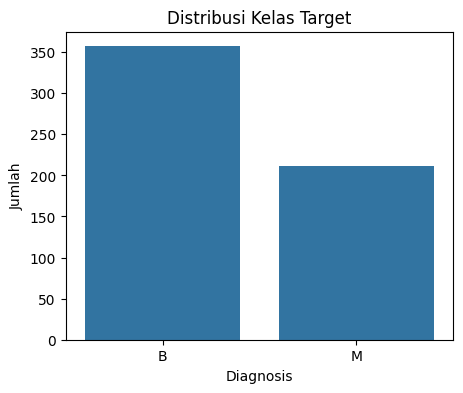

diagnosis
B    0.627417
M    0.372583
Name: count, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df['diagnosis'].value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
plt.title('Distribusi Kelas Target')
plt.show()
print(class_counts / len(df))

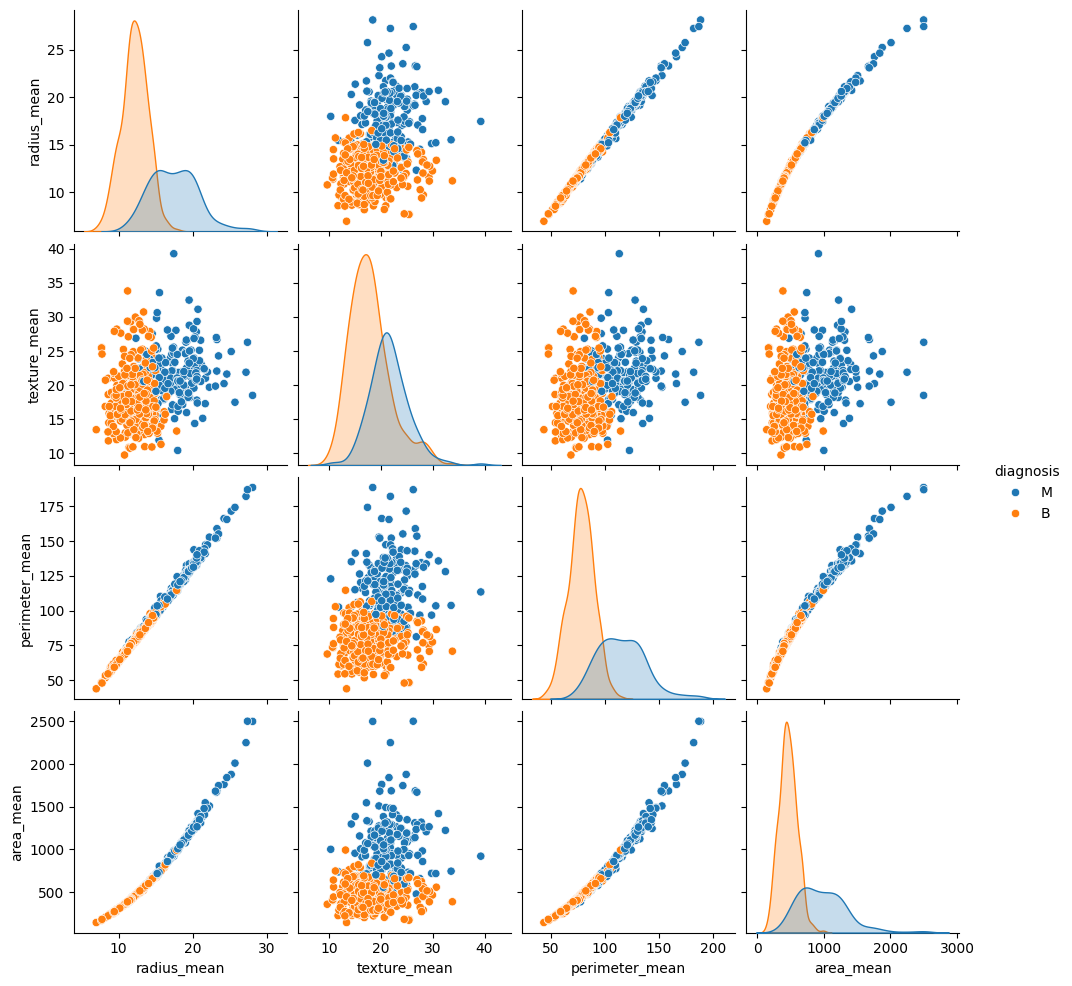

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
sns.pairplot(df[features + ['diagnosis']], hue='diagnosis')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = df.drop(columns=['Unnamed: 32'])
print(df.isnull().sum().sum())

0


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [9]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=1, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_scaled)

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
models_C = {}
for C in C_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    models_C[C] = model

In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = []
test_acc = []
for C in C_values:
    train_acc.append(accuracy_score(y_train, models_C[C].predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, models_C[C].predict(X_test_scaled)))
results_C = pd.DataFrame({'C': C_values, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})
display(results_C)

,C,Train Accuracy,Test Accuracy
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


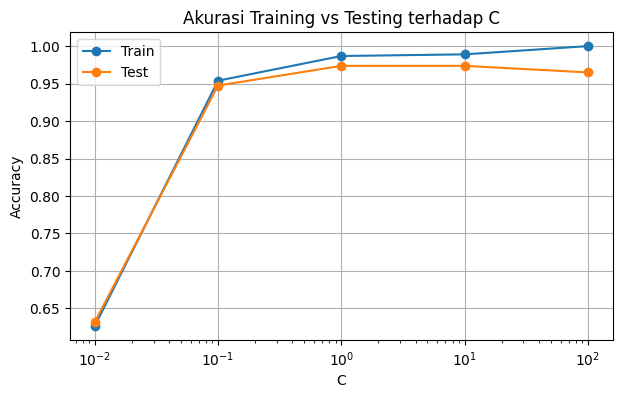

In [15]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(7, 4))
plt.semilogx(C_values, train_acc, marker='o', label='Train')
plt.semilogx(C_values, test_acc, marker='o', label='Test')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Testing terhadap C')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
preds = {'Linear': y_pred_linear, 'RBF': y_pred_rbf}
metrics = pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall': recall_score(y_test, p),
        'F1-Score': f1_score(y_test, p)
    } for name, p in preds.items()
}).T
display(metrics)

,Accuracy,Precision,Recall,F1-Score
Linear,0.964912,1.0,0.904762,0.950000
RBF,0.973684,1.0,0.928571,0.962963


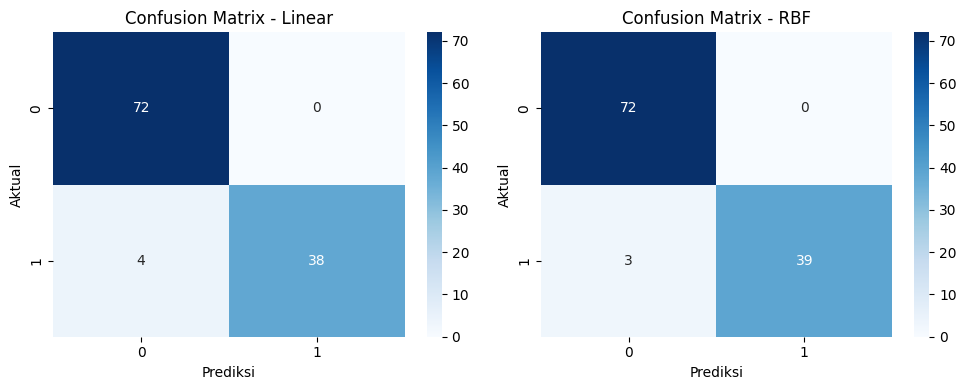

In [17]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, p) in zip(axes, preds.items()):
    sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

In [18]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
best_name = 'Linear' if accuracy_score(y_test, y_pred_linear) >= accuracy_score(y_test, y_pred_rbf) else 'RBF'
best_model = svm_linear if best_name == 'Linear' else svm_rbf
print('Model terbaik:', best_name)
print('Support vectors per kelas (Linear):', svm_linear.n_support_, 'total:', svm_linear.support_vectors_.shape[0])
print('Support vectors per kelas (RBF):', svm_rbf.n_support_, 'total:', svm_rbf.support_vectors_.shape[0])

Model terbaik: RBF
Support vectors per kelas (Linear): [19 19] total: 38
Support vectors per kelas (RBF): [50 57] total: 107


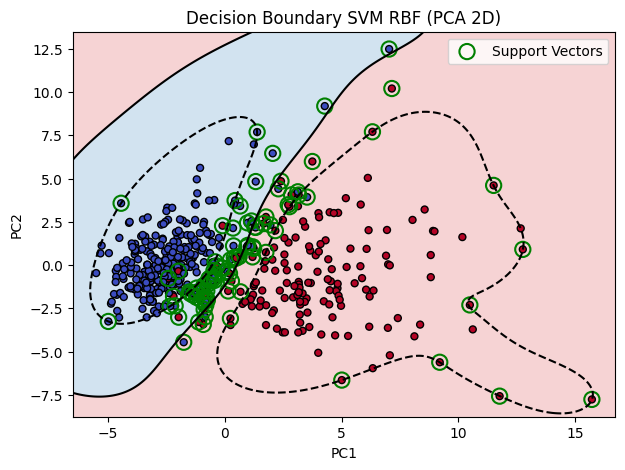

In [19]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
model_2d = SVC(kernel=best_model.kernel, C=best_model.C, gamma='scale')
model_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['tab:blue', 'tab:red'])
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=25)
plt.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1], s=120, facecolors='none', edgecolors='green', linewidths=1.5, label='Support Vectors')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Decision Boundary SVM {best_name} (PCA 2D)')
plt.legend()
plt.show()

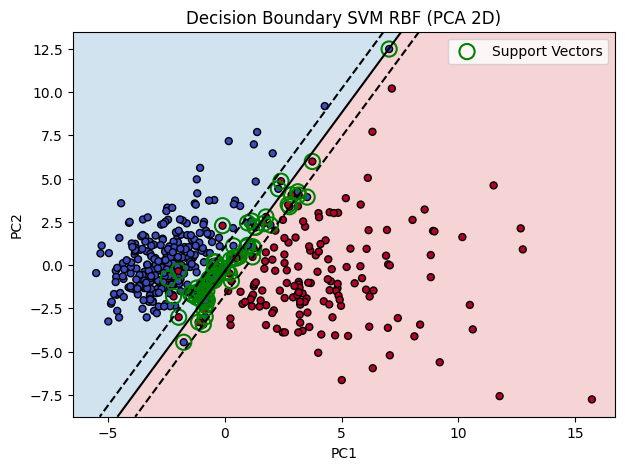

In [22]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
model_2d = SVC(kernel='linear', C=svm_linear.C, gamma='scale')
model_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['tab:blue', 'tab:red'])
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=25)
plt.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1], s=120, facecolors='none', edgecolors='green', linewidths=1.5, label='Support Vectors')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Decision Boundary SVM {best_name} (PCA 2D)')
plt.legend()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

- Perbedaan peforma tidak signifikan, karena persebaran data bisa dipisahkan dengan garis lurus atau lingkaran. Persebaran datanya jelas perbedaan nya antar daerah 0 dan 1 dan tidak berbentuk lingkaran jadi Kernel Linear bekerja dengan baik
- Nilai C terbaik adalah 1 diatas itu sudah menuju ke overfit seperti pada C = 100 train terlihat train akurasinya 100 tapi test akurasinya lebih buruk dari C=1, atau dari grafik train akurasinya naik tapi test akurasinya menurun
- Support vector lebih banyak di RBF karena bentuknya mengeliling seperti lingkaran sehingga lebih banyak berbatasan dengan support vector yang menyebabkan bentuk pengelompokkan keputusan lebih kompleks

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulam:
- Nilai C sangat berpengaruh ke akurasi dan bisa overfit atau underfit sehingga perlu dilakukan percobaan
- Perbedaan peforma pada data ini dengan RBF dan Linear tidak terlalu pengaruh karena pengelompokkan dari PCA sederhana
- RBF dikhususkan untuk mengelompokkan data dengan distribusi lebih kompleks

Saran:
- Seperti saran dari asdos dimana bisa dicoba kernel polynomial, hyperparameter tuning dengan GridSearchCV dan membandingkan dengan model lain
- Bisa dicoba dengan pengelompokkan data dengan distribusi yang lebih kompleks sehingga bisa terlihat perbedaan peformanya